# K-Nearest Neighbors (Classification)

## Intuition
$k$-Nearest Neighbors (KNN) is a supervised learning algorithm used for both classification and regression tasks. KNN works by identifying the $k$ closest neighbors (data points) to a given input and making a prediction based on the majority class (for classification) or the average value (for regression). Here, we’ll focus on classification and begin with a simple real-world example to build some intuition.

***
*Suppose a new movie has just been released and you are trying to decide whether you should watch it. You have not seen the movie yourself; however, many of your friends have seen it and share similar movie tastes to yours.*

*You ask a few friends for their opinions, and for each friend you also know how similar their tastes are to yours. To make your decision, you decide to only ask friends whose preferences are most similar to yours. Let’s say you consider the opinions of your five most similar friends. If the majority of those friends enjoyed the movie, you would decide the movie is worth watching.*
***

This is the idea behind $k$-Nearest Neighbors:
- Each friend represents a data point.
- How similar a friend’s taste is to yours corresponds to distance.
- The value of $k$ is the number of friends’ opinions you choose to consider.
- The final decision is made by taking a majority vote among those friends.

It should be noted that if you had chosen a smaller number of friends (for example, $k=3$), your decision would depend on very few opinions and could change easily. Alternatively, if you had chosen a larger number of friends, you would include people whose tastes are less similar to yours, which might influence the decision in a different way.

Additionally, it is generally encouraged to avoid choosing an even value for $k$. When $k$ is even, it is possible for the nearest neighbors to be split evenly between classes, resulting in a tie. In this case, the algorithm has no clear majority to determine the predicted class. Ties are typically resolved by selecting the class of the closest neighbor or by using distance-weighted voting.

$k$-Nearest Neighbors applies this same reasoning to data. Instead of friends and movie preferences, we work with data points and features. Instead of opinions, we work with class labels. To classify a new data point, the algorithm looks at the $k$ most similar points in the dataset and lets them decide the outcome.



  

## Formal Definition of k-Nearest Neighbors

## Implementing a KNN Classifier with Scikit-Learn

Introduction paragraph. 

**Import libraries**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

**Load Data**

In [30]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map(dict(enumerate(target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


As we can see...

In [33]:
feature_x = "sepal length (cm)"
feature_y = "sepal width (cm)"

In [34]:
X_2d = df[[feature_x, feature_y]].to_numpy()
y = df["target"].to_numpy()

X_2d.shape, y.shape

((150, 2), (150,))

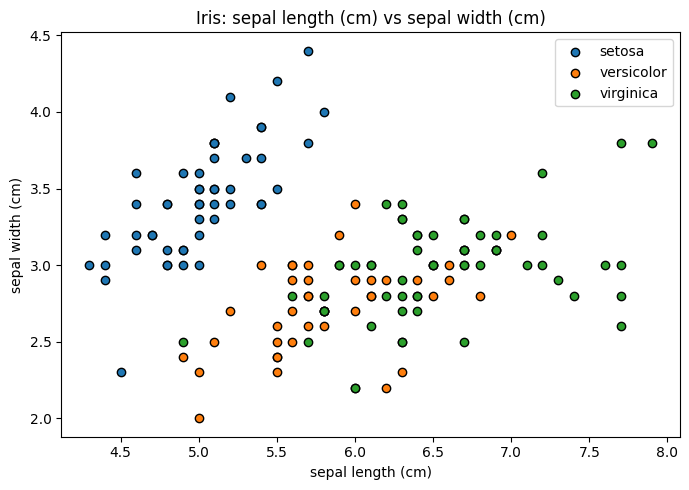

In [35]:
plt.figure(figsize=(7, 5))

for class_id, class_name in enumerate(target_names):
    subset = df[df["target"] == class_id]
    plt.scatter(subset[feature_x], subset[feature_y], label=class_name, edgecolor="k")

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"Iris: {feature_x} vs {feature_y}")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((105, 2), (45, 2))

In [37]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [39]:
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy (k={k}): {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df

Test accuracy (k=5): 0.800


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,11,4
virginica,1,4,10


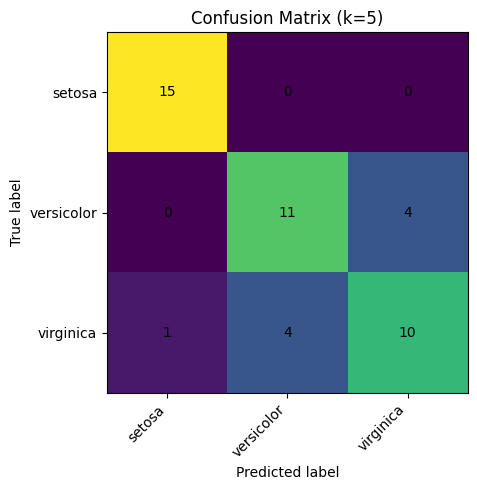

In [40]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (k={k})")
plt.xticks(np.arange(len(target_names)), target_names, rotation=45, ha="right")
plt.yticks(np.arange(len(target_names)), target_names)

# write the counts on the plot
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

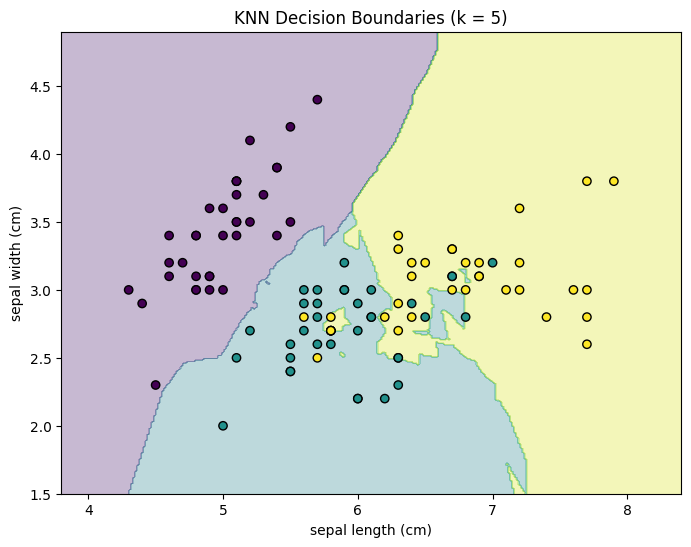

In [41]:
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid_points)
Z = Z.reshape(xx.shape)


plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Training points
scatter = plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k"
)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"KNN Decision Boundaries (k = {k})")
plt.legend(handles=scatter.legend_elements()[0], labels=target_names)
plt.tight_layout()
plt.show()


**Create and train the KNN classifier:**

KNeighborsClassifier comes with many parameters which you can adjust as needed

```n_neighbors```

```algorithm```

```leaf_size```

```p```

```metric```

```metric_params```

```n_jobs```



In [18]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**Make predictions:**

In [19]:
y_pred = knn.predict(X_test)

**Evaluate model performance:**

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)
print(cm)

Test accuracy: 0.978
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


**Visualise predictions using two features:**


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

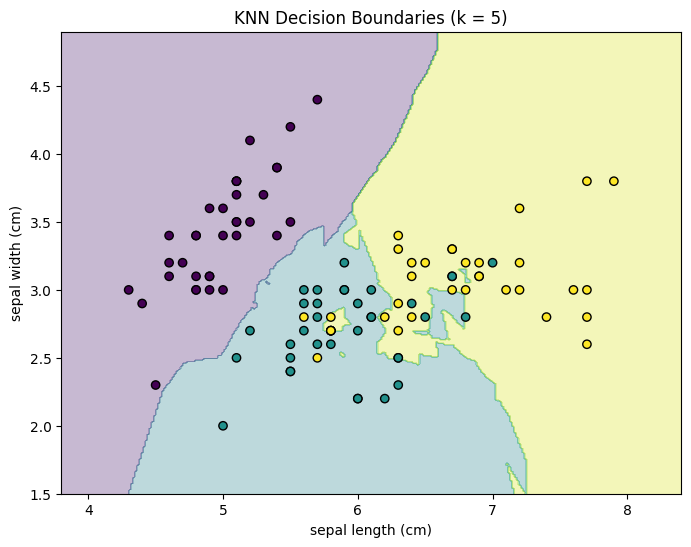

In [21]:
X_2d = X[:, :2]  # first two features only

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d, y_train_2d)

# Create a mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict class for each grid point
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training points
scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_2d,
    edgecolor="k"
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("KNN Decision Boundaries (k = 5)")
plt.legend(handles=scatter.legend_elements()[0], labels=target_names)
plt.show()


## Building a KNN Classifier from First Principles

**Imports:** 

```numpy``` is used for numerical computation, allowing us to represent feature vectors as arrays and compute distances between data points using fast, vectorised operations.

```pandas``` is used to load and manipulate data from CSV files, making it easy to select feature columns and labels before converting them into NumPy arrays.

```matplotlib``` is used to visualise the data and the behaviour. This includes plotting data, decision boundaries, and model performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Loading in your data:**

In [ ]:
data = pd.read_csv('data.csv')

X = data[features].to_numpy()
y = data[labels].to_numpy()

NameError: name 'data' is not defined

**Notes:**

***
**Complete KNN Classifier:**

***